In [328]:
import numpy as np 
import pandas as pd 
from sklearn.datasets import load_breast_cancer

In [329]:
data=load_breast_cancer()
df=pd.DataFrame(data.get('data'),columns=data.get('feature_names'))
target=pd.DataFrame(data.get('target'),columns=['target'])
df.head()
target.head()

,target
0,0
1,0
2,0
3,0
4,0


In [330]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df,target,random_state=42,test_size=0.2)

In [331]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
obj=LogisticRegression()
obj.fit(x_train,y_train)
pred=obj.predict(x_test)
pred

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

In [332]:
from sklearn.metrics import accuracy_score, classification_report
print('Accuracy Score:',accuracy_score(y_test,pred))
print(f'whole Classification report \n{classification_report(y_test,pred)}')

Accuracy Score: 0.9473684210526315
whole Classification report 
              precision    recall  f1-score   support

           0       0.97      0.88      0.93        43
           1       0.93      0.99      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



### Perceptron Trick from scratch 

In [333]:
df=pd.read_csv(r'D:\projects\project1\datasets\logistic_regression_data_2features.csv')

In [334]:
df.shape

(100, 3)

In [335]:
df['feature0']=np.full((100,),1)

In [336]:
df.columns

Index(['feature1', 'feature2', 'target', 'feature0'], dtype='str')

In [337]:
df.head()

,feature1,feature2,target,feature0
0,-4.774390,-1.128783,1,1
1,-3.135826,-0.535217,1,1
2,4.465239,-2.012233,0,1
3,-4.281804,-0.878251,1,1
4,3.407545,-2.664642,0,1


In [338]:
y=df['target'].to_numpy()
x=df.drop(columns=['target'],inplace=False).to_numpy()

In [339]:
len(x[0])

3

In [340]:
def perceptron(x,y,epoch=1000,n=0.05):
    weights=np.full((len(x[0]),),1)
    a=np.random.randint(0,len(x),epoch)
    for i in a:
        weights=weights-n*(predict(x[i],weights)-y[i])*x[i]
    return weights
def predict(x,weights):
    a=x@weights
    if a>0:
        return 1
    return 0


In [341]:
weight=perceptron(x,y,epoch=500,n=0.04)

In [342]:
a,b,c=weight[0],weight[1],weight[2]
m=(-a)/b
e=(-c)/b
k=np.linspace(-6,6,100)
l=[]
for i in k:
    a=m*i+e
    l.append(a)
l=np.array(l)


In [343]:
import seaborn as sns 
import matplotlib.pyplot as plt

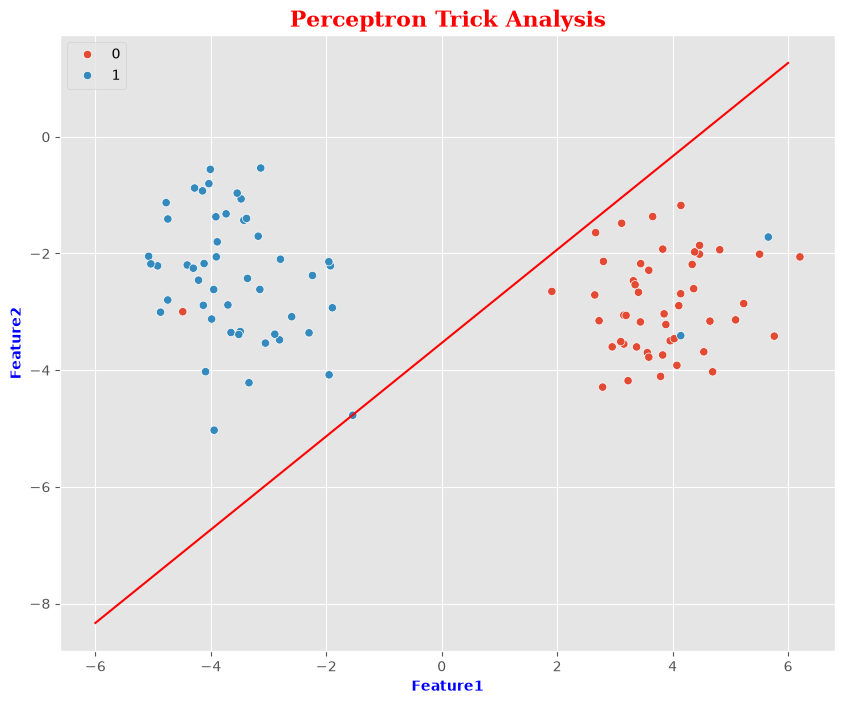

In [344]:
text={'fontsize':16,'fontweight':'bold','color':'red','loc':'center','fontfamily':'serif'}
plt.style.use('ggplot')
plt.figure(figsize=(10,8))
sns.scatterplot(df,x='feature1',y='feature2',hue='target')
plt.plot(k,l,color='red')
plt.legend(loc='best')
plt.title('Perceptron Trick Analysis',**text)
plt.xlabel('Feature1',fontweight='bold',fontsize=10,color='blue')
plt.ylabel('Feature2',fontweight='bold',fontsize=10,color='blue')
plt.show()